In [2]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')

    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)



    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)


def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):

    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]

    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)

    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')

    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])


    return X_train,y_train,X_val,y_val,X_test,y_test

In [3]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.19.0
3.10.0


In [4]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer",
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Dataset not found. Downloading...


/tmp/ipykernel_300/3806609017.py:41: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tfile.extractall(path=path)


Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


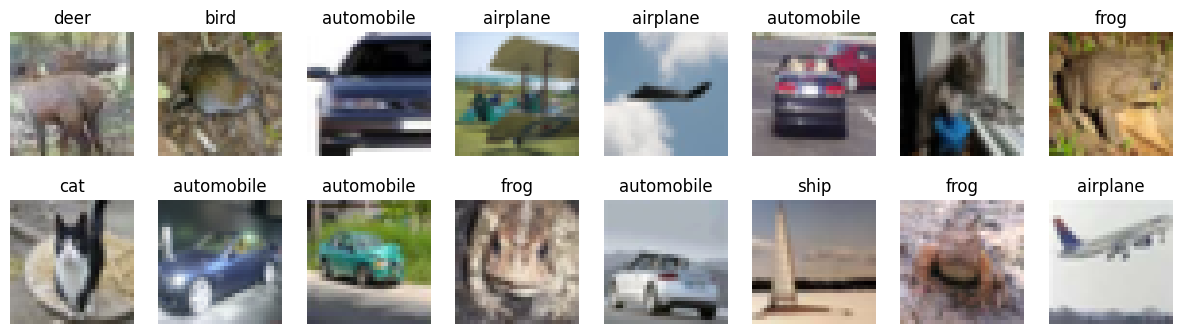

In [5]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

In [6]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [7]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization, Input
from keras.layers import LeakyReLU

In [8]:
def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """

    model = Sequential()

    model.add(Input(shape=(32,32,3)))

    model.add(keras.layers.RandomFlip("horizontal"))

    model.add(Conv2D(filters=64,
                 kernel_size=(3,3),
                 padding="same",
                 activation="relu",
                 input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=64,
                 kernel_size=(3,3),
                 padding="same",
                 activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2))) #splits matrices so the image isnt too many pixels so the model classifies more easily
    model.add(Dropout(0.15))


    model.add(Conv2D(filters=128,
                 kernel_size=(4,4),
                 padding="same",
                 activation="relu",
                 input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=128,
                 kernel_size=(4,4),
                 padding="same",
                 activation="relu"))
    model.add(MaxPooling2D((2,2)))
    #^splits matrices so the image isnt too many pixels so the model classifies more easily
    model.add(Dropout(0.15))


    model.add(Conv2D(filters=128,
                 kernel_size=(4,4),
                 padding="same",
                 activation="relu",
                 input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(filters=128,
                 kernel_size=(6,6),
                 padding="same",
                 activation="relu",
                 input_shape=(32,32,3)))
    model.add(MaxPooling2D((2,2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.55))
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(0.45))

    model.add(Dense(10, activation="softmax"))

    ### --> Build your convolutional neural network.
    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.
    ### Then, add a Pooling layer to pick up the relevant kernels.
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,
    ###  to learn the relevant combinations of low-level kernel features.
    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes.


    # Ensure normalized probabilities over the 10 classes


    return model
print(x_train.shape) #we have a 32x32 RGB
model = make_model()
model.summary()

(40000, 32, 32, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,557,130 (5.94 MB)

 Trainable params: 1,556,362 (5.94 MB)

 Non-trainable params: 768 (3.00 KB)

***All of my knowledge on the functionality of this model comes from: https://keras.io/api/***


The above code cell is my final attempt at a CNN network.

It works by first defining the shape of the training data ("model.add(Input(shape=(32,32,3)))" $\rightarrow$ A 32x32 RGB picture). It then tells the model to randomly flip these pictures horizontally to increase the possible training data range.

The CNN network in itself is comprised of three blocks:

**Block 1:**

**model.add(Conv2D(filters=64, padding="same", activation="relu", input_shape=(32,32,3)))**:

Applies 64 CNN filters (small kernels of a 3x3 size) onto the training image. My intuiton for this Conv2D layer was to pick up small clumps of same-colored pixels.

**model.add(BatchNormalization())**
translates the values picked up by the Conv2D layer by normalising them with **~N(0,1)** ($\mu$ = 0 and $\sigma$ = 1). What this does is it gets rid of values that might skyrocket when compared to the rest of the image.


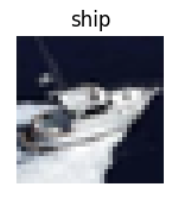

The above picture is a pretty good example, as there is a sharp contrast between the ship (which has high RGB values as it is white) and the water around it with low RGB values. After the first Conv2D layer the batch normalisation would rescale these high contrasts so that the next batch of filters doesnt get confused by the large difference and trains more efficiently.

The next Conv2D layer then focuses on creating more shapes out of the already trained relations.

lastly, block one uses **model.add(MaxPooling2D((2,2)))** which takes the max values out of feature maps created (A map of edges and textures picked up by the kernels) of pixels and keeps that value. It essentially downscales the images making the model less sensitive to exact pixels, allowing it to instead focus on small changes in the trained datasamples. (It does this through a 2x2 block of pixels → 4 pixels per pool) and then randomly **Drops out** 15% of the activators (whatever the model learned) to account for any inaccuracy and possible overfitting.

The other Conv2D blocks follow the same logic with increased filter sizes, allowing the network to detedct more distinct patterns, and larger kernels. What this does is it picks up larger chunks of patterns, for example the next block could pick up eyes, water, circles etc.

After all these layers, the values are **Flattened**, turning them into 1D vectors which then pass through dense layers, which learn combinations of the shapes extracted by the Conv2D layers (the beforementioned "eyes" etc.). My model uses two **Dense** layers, **Dense(128)** followed by **Dense(64)**. It first predicts large features, and then refines them into more class specific features (an example would be distinguishing the shape of a deer with the shape of a cat.) Each dense layer is followed by a decreasing **Dropout** so that the model doesnt overfit by remembering the training data as dense layers have significantly more parameters than the Conv2D layers.

Lastly **Dense(10, "Softmax")** is used, which takes these predictions and converts them into a probability of being within each of the defined classes. All of these have to sum to 1.






Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.1632 - loss: 2.2841 - val_accuracy: 0.1746 - val_loss: 2.2835 - learning_rate: 5.0000e-04
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.2798 - loss: 1.9708 - val_accuracy: 0.4849 - val_loss: 1.6602 - learning_rate: 5.0000e-04
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.3731 - loss: 1.7469 - val_accuracy: 0.5572 - val_loss: 1.3284 - learning_rate: 5.0000e-04
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.4563 - loss: 1.5527 - val_accuracy: 0.6299 - val_loss: 1.1168 - learning_rate: 5.0000e-04
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.5187 - loss: 1.3827 - val_accuracy: 0.6447 - val_loss: 1.0487 - learning_rate: 5.0000e-04
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.5731 - loss: 1.2541 - val_accuracy: 0.6871 - val_loss: 0.9303 - learning_rate: 5.0000e-04
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 4

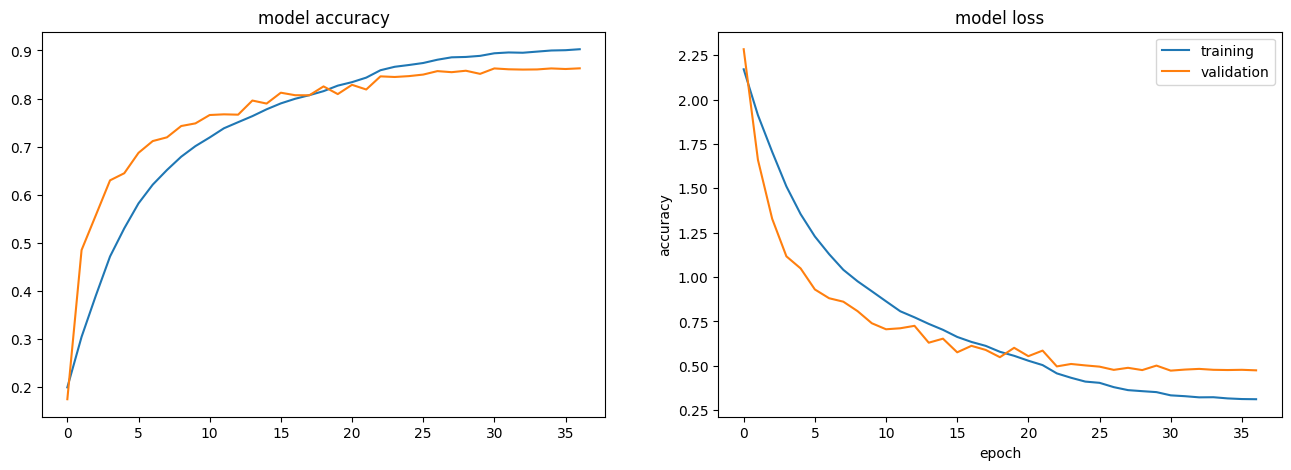

In [9]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10, # stop if no improvement for 10 epochs
    min_delta=0.01,
    restore_best_weights=True  # revert to the best epoch automatically
                          )

reduce_lr = ReduceLROnPlateau(monitor = "val_loss",
                              factor = 0.5,
                              patience = 3, #seems to be going up and down every 3 epochs in my code
                              cooldown = 0,
                              min_delta=0.01,
                              min_lr = 5e-6
                              )

INIT_LR = 5e-4 # i found this value didnt overshoot weights.
BATCH_SIZE = 128 #i found this value to be a good middle ground between the speed of training and accuracy
EPOCHS = 100# num of times that the model trains on the data


K.clear_session()  # clear default graph
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model

# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adamax(learning_rate=INIT_LR),  # for SGD.
    metrics=['accuracy']  # report accuracy during training
)

# fit model
history = model.fit(
    x_train, y_train,  # prepared data
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
    callbacks=[early_stop, reduce_lr]
)

plt.figure(figsize=[16,5])

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Value of accuracy")
plt.title("model accuracy")

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Training loss")
plt.title("model loss")


plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["training", "validation"], loc="best")
plt.show()
# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

In [10]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


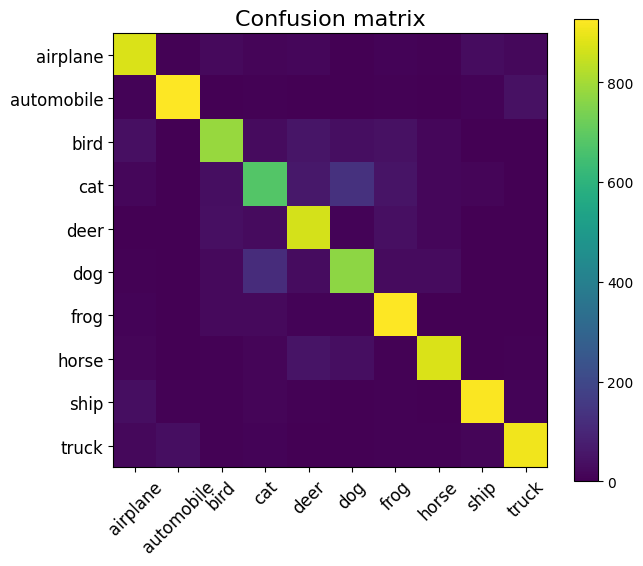

Test accuracy: 0.8522


In [13]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

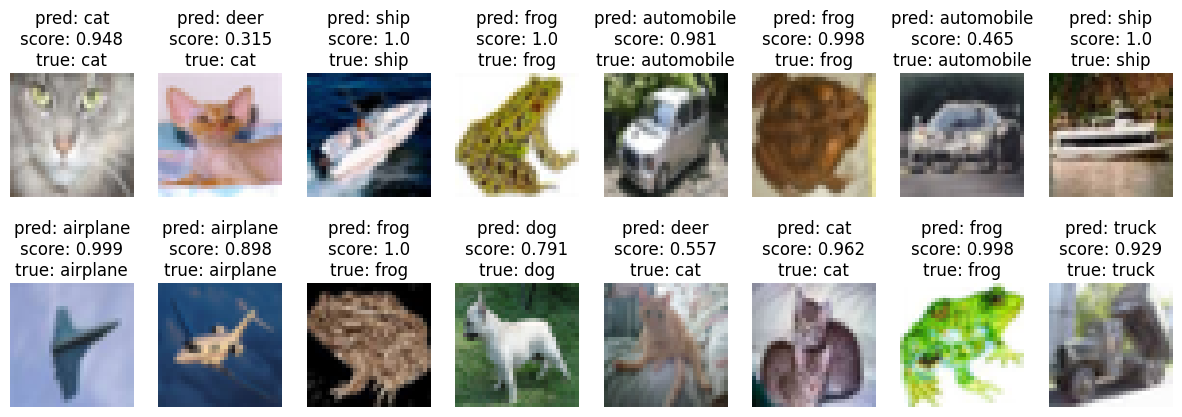

In [12]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons,
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ -
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.




Below are some of my previous attempts before deciding on the final model.

**Lowest accuracy model (69%)**:



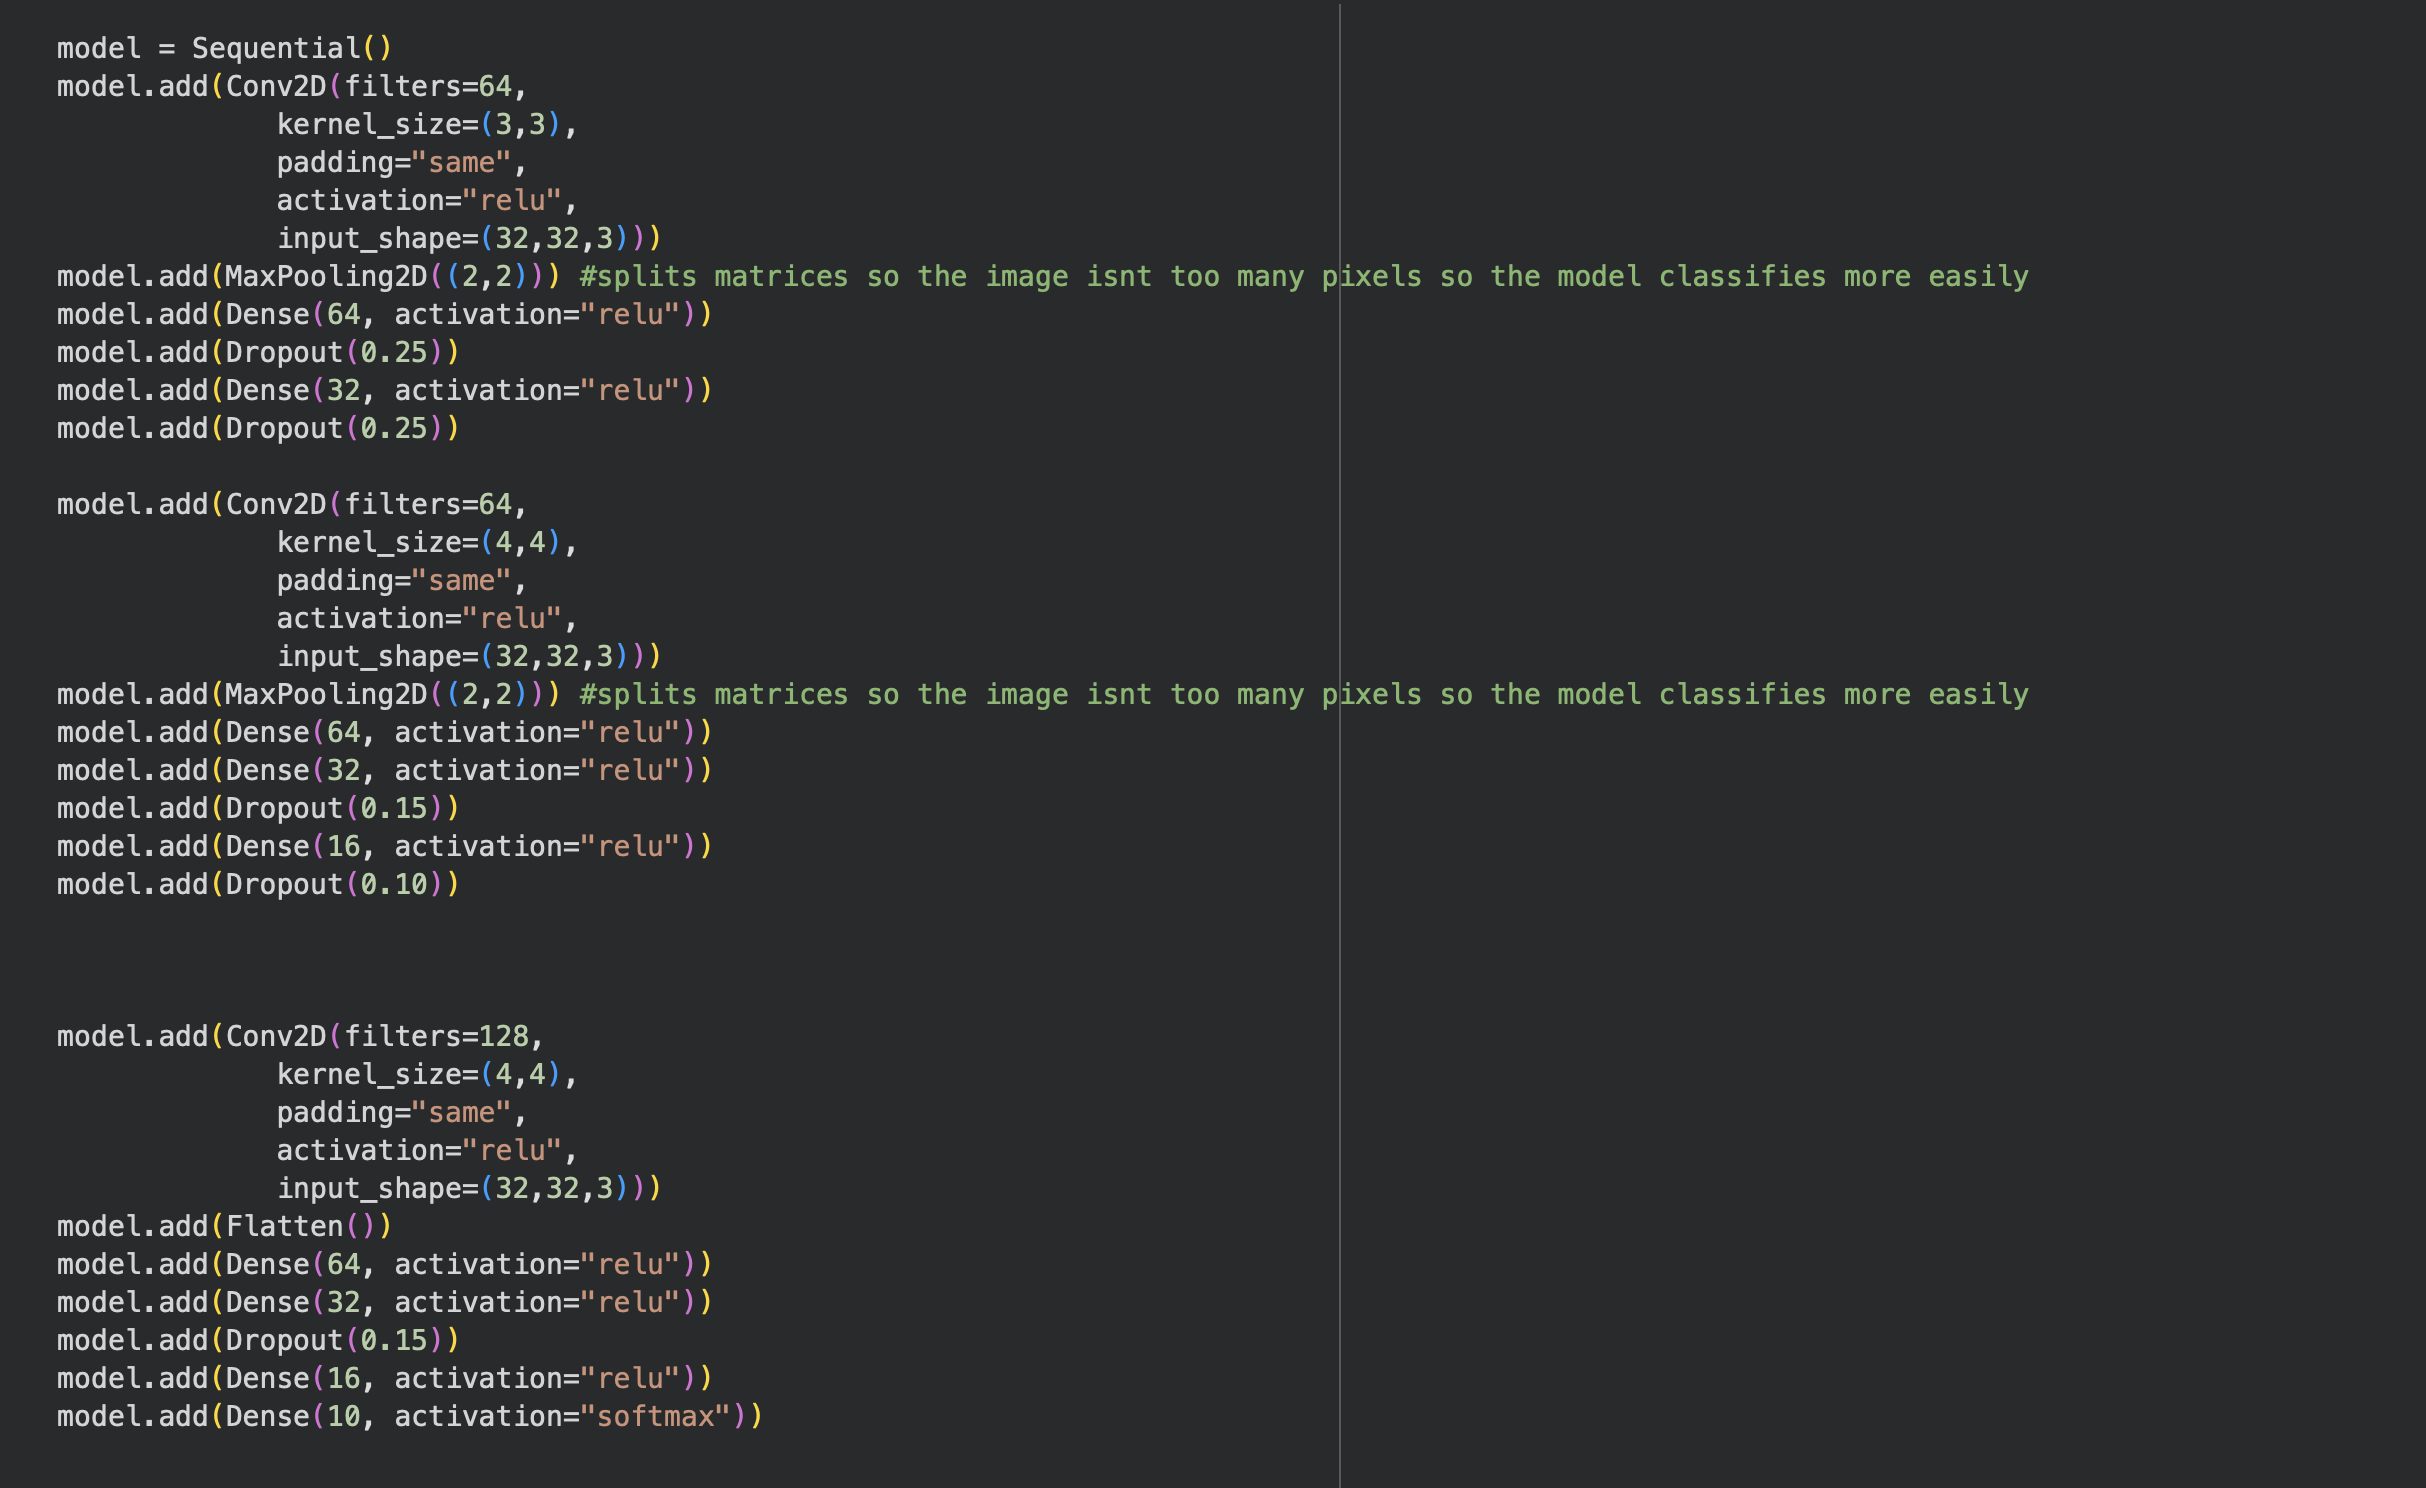

During this attempt i didnt fully understand what the **Dense()** layer actually does. What the model essentially is doing is its trying to pass a 3D vector with shape and RGB values onto a layer which only accepts a 1D vector (expecting pixel RGB values), so instead it just takes the last dimension, treating combined RGB channels as a 1D vector, which is really not what the model should be training on.

From this attempt i learned to create a layer, which is **Flattened**, creating that 1D vector, and then passing that through the final **Dense** layers.

**Second Attempt (Overfitting)**:

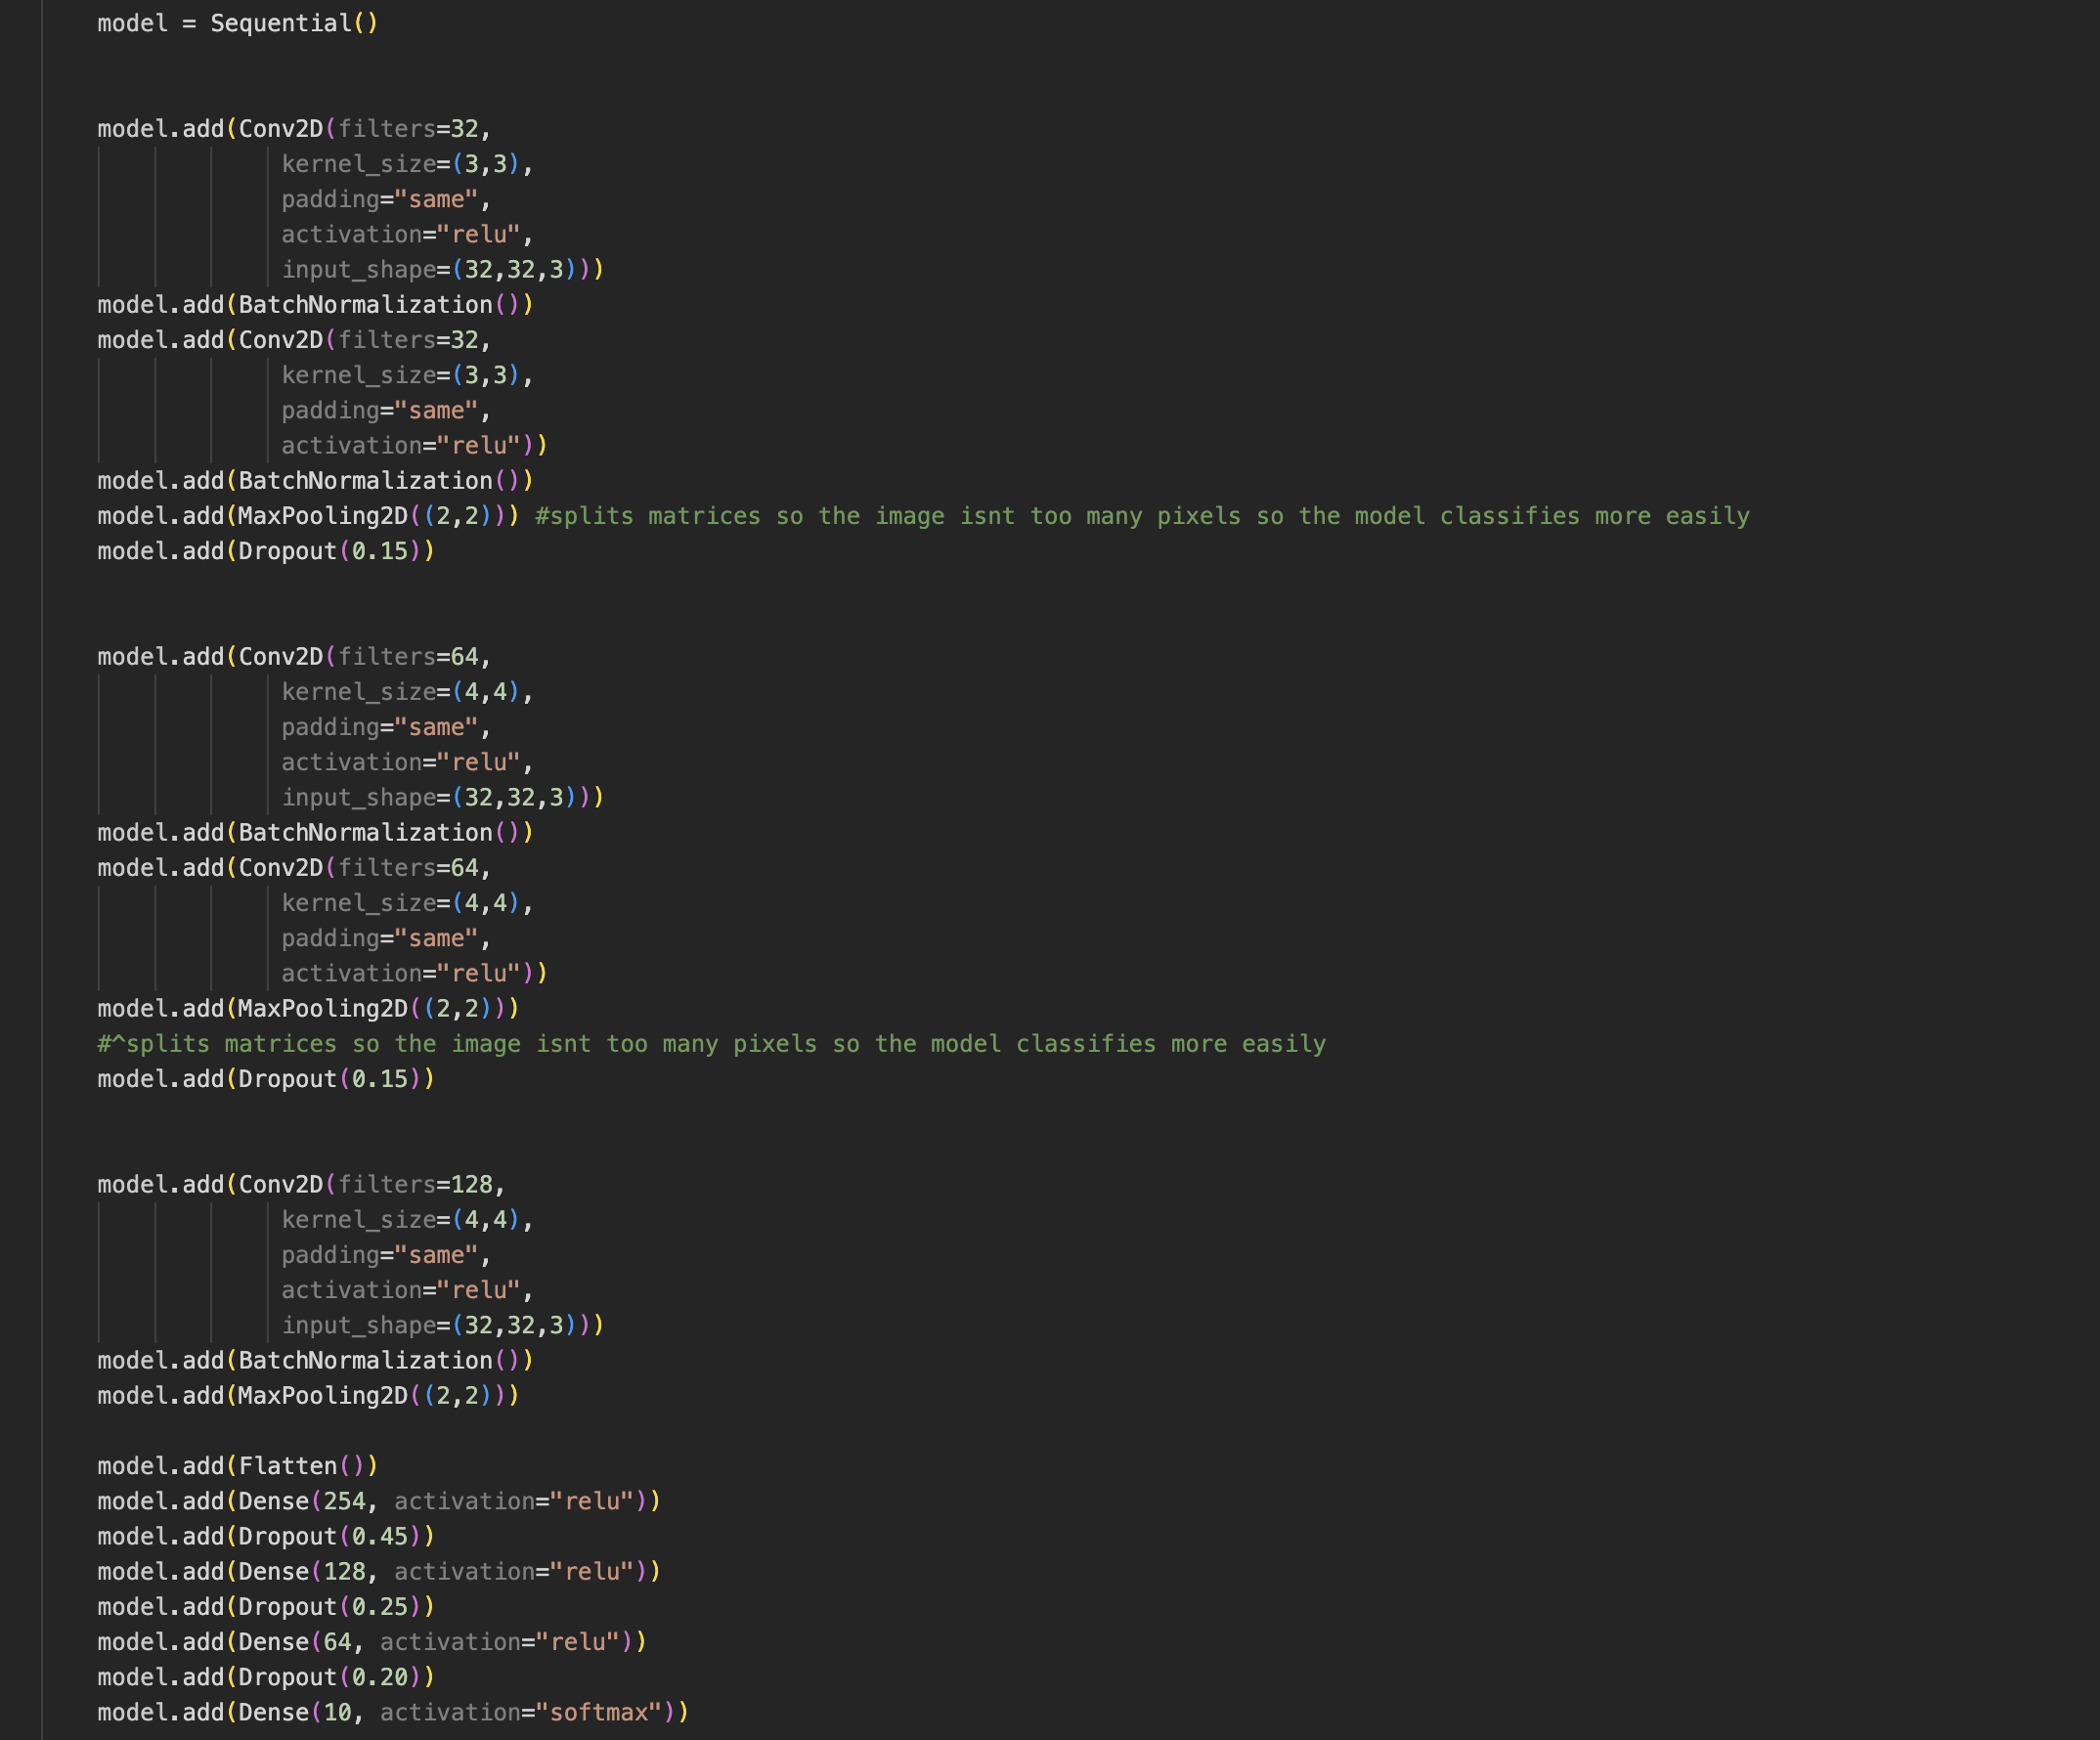

During my second attempt i noticed an increase in accuracy of the model, however i also noticed that over 60 epochs the model only got better at matching the training dataset, whereas the random picture dataset's accuracy stayed around the same value, i.e. **overfitting**. Overfitting happens when the model starts remembering the training data instead of just noticing patterns.

 I confirmed this by plotting the validated data and the training data over epochs:

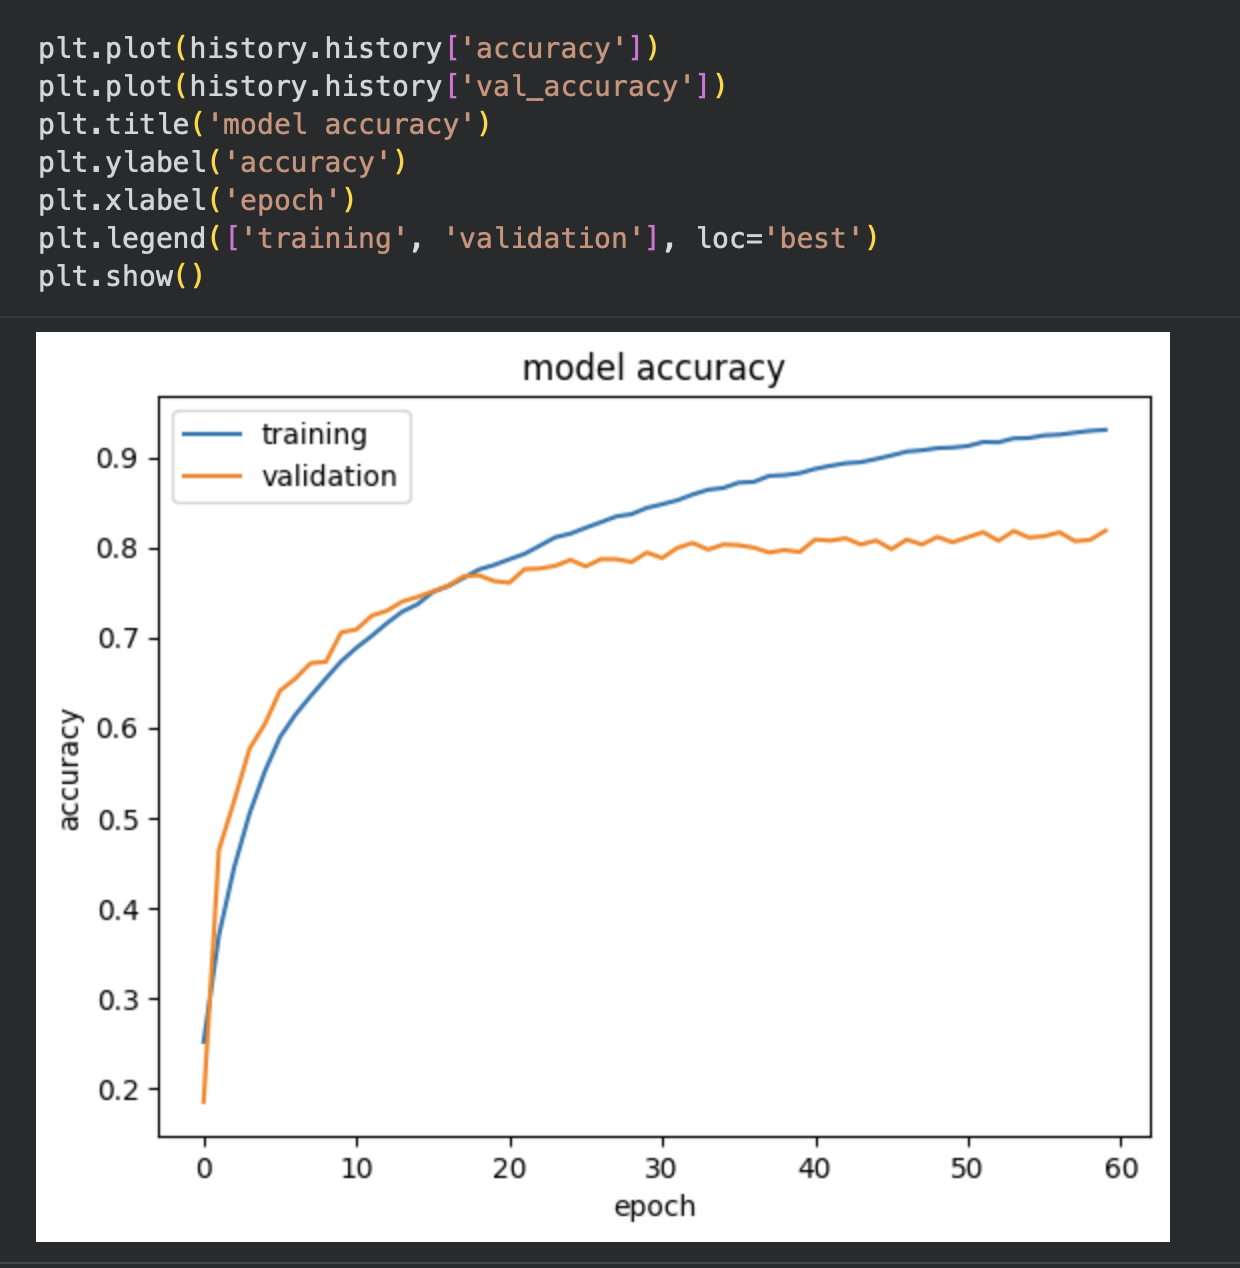

This led me to create two functions, **early_stop** and **reduce_lr**.

**early_stop = EarlyStopping( monitor='val_accuracy', patience=10, min_delta=0.01, restore_best_weights=True  
)**

This function utilises **EarlyStopping** from the keras.callbacks library. It monitors the "*val_accuracy*"  variable, and if it doesn't see it change by 0.01 for 10 epochs straight it stops the learning process and reverts to the epoch with the highest validation accuracy.
This allowed me to increase the epochs to 100, because no matter the amount it would stop whenever the model reached its best *validation* values.

**reduce_lr = ReduceLROnPlateau(monitor = "val_loss",
factor = 0.5,
patience = 3,
cooldown = 0,
min_delta=0.01,
min_lr = 5e-6)**

This function also utilises keras.callbacks, and reduces the learning rate of the model by half whenever theres no change of *val_loss* larger than 0.01 (because *val_loss* is what defines the models confidence in validating data), it continues to do so until it reaches a hardcoded learning rate limit of $5*10^-6$. During different runs i noticed my code would get stuck for around 3 epochs in my code (i.e. it got stuck in a local minimum, hence i minimised the learning, which forces the model to take more precise steps.)

